# Естественные и синтетические научные тексты

Сравниваю тексты, написанные людьми, с текстами языковых моделей по трём линиям. Первая это лингвостатистический профиль по Profiling-UD, вторая семантика (BERTScore, BARTScore, Self-BLEU и несколько своих метрик), третья качество классификаторов на этих признаках.

## Данные

**Английский, AIGTxt.** Абзацы из научных статей до 2022 года. В каждой строке три версии одного абзаца: исходный человеческий текст, его пересказ ChatGPT и смешанный текст (половина от человека, половина от ChatGPT). Благодаря такой парности BERTScore и BARTScore можно честно считать относительно исходника, а на кросс-валидации группировать строки, чтобы пересказ одного абзаца не оказался одновременно в обучении и в тесте.

**Русский, AINL-Eval-2025.** Научные аннотации, написанные человеком или сгенерированные gpt-4-turbo, llama-3.3-70b и gemma-2-27b по названию и ключевым словам статьи. Пар здесь нет, каждый текст написан независимо.

## Коротко о результатах

- ИИ-текст на обоих языках лексически плотнее и однообразнее по синтаксису. В английском у него длиннее слова, меньше связок и вспомогательных глаголов, больше причастий и герундиев. В русском у него короче синтаксические связи, больше сочинения и прямых дополнений, почти нет чисел.
- Семантически пересказ ChatGPT держится близко к исходнику, BERTScore 0.66 против −0.10 у случайного текста той же области. Русские ИИ-аннотации между собой похожи сильнее, чем человеческие: Self-BLEU 0.13–0.15 против 0.05.
- Классификаторы на признаках Profiling-UD дают macro F1 0.84 на английском и 0.92 на русском (human против ai), с добавлением LM-признаков 0.87 и 0.93. TF-IDF слов всё равно сильнее, 0.95 и 0.93. Смешанные тексты распознаются плохо.

Запуск и файлы описаны в README.md. Первый прогон с нуля занимает около часа (разбор stanza и языковые модели), дальше всё берётся из cache/.

In [1]:
import os, pickle, warnings; warnings.filterwarnings('ignore')
os.environ['HF_HOME'] = 'cache/hf'; os.environ['STANZA_RESOURCES_DIR'] = 'cache/stanza'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
import xgboost  # на macOS строго до torch, иначе две копии OpenMP роняют ядро
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

from prep_data import load_en, load_ru
from profiling_ud import profile, to_conllu

SEED = 42
os.makedirs('results', exist_ok=True)
pd.set_option('display.width', 200, 'display.max_columns', 40, 'display.precision', 4)
sns.set_theme(style='whitegrid', font_scale=0.9)

def cached(path, fn):
    if os.path.exists(path):
        return pd.read_parquet(path)
    df = fn(); df.to_parquet(path); return df

## 1. Данные

Из AIGTxt беру 1500 случайных строк, это 4500 текстов по 1500 на класс, три дубля человеческого текста выбрасываю. Из русского train беру по 1200 текстов на каждый из четырёх источников, всего 4800. В бинарной задаче три модели объединены в класс ai.

In [2]:
en, ru = load_en(), load_ru()
for name, d in [('en', en), ('ru', ru)]:
    d['n_words'] = d.text.str.split().str.len()
print(f'en {en.shape}, ru {ru.shape}\n')
print(en.groupby('label').n_words.describe()[['mean', '50%', 'min', 'max']].round(0))
print()
print(ru.groupby('model').n_words.describe()[['mean', '50%', 'min', 'max']].round(0))

en (4500, 5), ru (4800, 4)

         mean    50%   min    max
label                            
ai      179.0  175.0  47.0  504.0
human   186.0  180.0  53.0  518.0
hybrid  182.0  177.0  43.0  519.0

                mean    50%   min    max
model                                   
gemma-2-27b     62.0   62.0  22.0  110.0
gpt-4-turbo     85.0   84.0  59.0  131.0
human          124.0  100.0  10.0  853.0
llama-3.3-70b   70.0   68.0  24.0  137.0


В английском длина у классов практически одинаковая, пересказ сохраняет объём. В русском человеческие аннотации заметно длиннее (медиана 100 слов против 62–84) и гораздо разнообразнее по длине, от 10 до 853 слов. Это ловушка: многие признаки зависят от длины, и классификатор может выучить её вместо стиля. Ниже я проверяю это двумя способами, частной корреляцией с поправкой на длину и отдельной базовой линией, в которой классификатор видит только длину.

## 2. Лингвостатистический профиль, Profiling-UD

Profiling-UD это веб-сервис ILC-CNR. Он разбирает тексты по Universal Dependencies и считает около ста признаков в семи группах: сырой текст, лексическое разнообразие, распределение частей речи, глагольная морфология, глагольные предикаты, структура дерева, подчинение. У сервиса нет API, поэтому я воспроизвела его признаки локально (profiling_ud.py) поверх разбора stanza, с теми же названиями и определениями.

На вход, как и в задании, отдельно подаются тексты каждого класса. В results/profiling_ud_input лежат CoNLL-U файлы по классам, их можно загрузить в оригинальный сервис для сверки. На выходе получаются CSV по классам: results/profiling_{lang}_{label}.csv.

In [3]:
def load_parses(lang, df):
    path = f'cache/ud_{lang}.pkl'
    if not os.path.exists(path):
        import stanza
        from profiling_ud import parse
        proc = 'tokenize,mwt,pos,lemma,depparse' if lang == 'en' else 'tokenize,pos,lemma,depparse'
        nlp = stanza.Pipeline(lang, processors=proc, verbose=False)
        pickle.dump(parse(nlp, df.text.tolist()), open(path, 'wb'))
    return pickle.load(open(path, 'rb'))

ud = {'en': load_parses('en', en), 'ru': load_parses('ru', ru)}

# тексты и разборы по классам отдельными файлами, как их подают в Profiling-UD
os.makedirs('results/profiling_ud_input', exist_ok=True)
for lang, d in [('en', en), ('ru', ru)]:
    for lab in d.label.unique():
        ix = np.where(d.label == lab)[0]
        with open(f'results/profiling_ud_input/{lang}_{lab}.conllu', 'w') as f:
            for i in ix:
                f.write(f'# newdoc id = {lang}_{lab}_{i}\n' + to_conllu(ud[lang][i]))

prof = {lang: pd.DataFrame([profile(s) for s in ud[lang]]) for lang in ud}
for lang, d in [('en', en), ('ru', ru)]:
    for lab in d.label.unique():
        prof[lang][d.label.to_numpy() == lab].to_csv(f'results/profiling_{lang}_{lab}.csv', index=False)
    print(f'{lang}: {prof[lang].shape[1]} признаков, {len(prof[lang])} текстов')
prof['en'].head(3)

en: 99 признаков, 4500 текстов
ru: 99 признаков, 4800 текстов


,n_sentences,n_tokens,tokens_per_sent,char_per_tok,ttr_form_chunks_100,ttr_lemma_chunks_100,ttr_form_chunks_200,ttr_lemma_chunks_200,upos_dist_ADJ,upos_dist_ADP,upos_dist_ADV,upos_dist_AUX,upos_dist_CCONJ,upos_dist_DET,upos_dist_INTJ,upos_dist_NOUN,upos_dist_NUM,upos_dist_PART,upos_dist_PRON,upos_dist_PROPN,...,max_links_len,avg_token_per_clause,verbal_head_per_sent,verbal_root_perc,avg_verb_edges,verb_edges_dist_0,verb_edges_dist_1,verb_edges_dist_2,verb_edges_dist_3,verb_edges_dist_4,verb_edges_dist_5,verb_edges_dist_6,n_prepositional_chains,avg_prepositional_chain_len,subj_pre,obj_post,principal_proposition_dist,subordinate_proposition_dist,subordinate_pre,avg_subordinate_chain_len
0,5,137,27.4,6.3689,0.75,0.73,NaN,NaN,11.6788,11.6788,1.4599,2.9197,3.6496,8.7591,0.0,35.7664,0.0,1.4599,0.0000,0.0,...,13,10.8667,2.8000,100.0000,2.7857,7.1429,7.1429,35.7143,14.2857,21.4286,14.2857,0.0,1.6000,1.25,100.0,100.0,38.4615,61.5385,37.5000,1.3750
1,6,141,23.5,5.4597,0.70,0.65,NaN,NaN,8.5106,4.9645,4.2553,6.3830,3.5461,5.6738,0.0,26.2411,0.0,2.8369,4.9645,0.0,...,16,6.2167,3.6667,83.3333,2.6364,4.5455,22.7273,18.1818,27.2727,13.6364,13.6364,0.0,0.3333,1.00,100.0,100.0,36.0000,64.0000,18.7500,1.5000
2,5,136,27.2,5.7724,0.73,0.70,NaN,NaN,11.7647,8.8235,2.9412,2.9412,3.6765,7.3529,0.0,31.6176,0.0,2.2059,3.6765,0.0,...,16,9.6600,3.2000,100.0000,2.7500,0.0000,25.0000,18.7500,18.7500,31.2500,6.2500,0.0,1.0000,1.20,100.0,100.0,31.5789,68.4211,23.0769,1.6154


## 3. Какие признаки отличают классы

Для каждого признака считаю три вещи:

- точечно-бисериальную корреляцию с меткой (r_pb);
- тест Манна–Уитни с поправкой Бенджамини–Хохберга на множественные сравнения, это около 90 тестов на язык;
- дельту Клиффа как размер эффекта. Она показывает, насколько чаще значение у ai больше, чем у human. Пороги стандартные: 0.147 малый, 0.33 средний, 0.474 большой.

При такой выборке значимым оказывается почти всё, поэтому признаки ранжирую по размеру эффекта, а не по p.

In [4]:
def cliffs_delta(a, b):
    """Доля пар, где a больше b, минус доля пар, где меньше. От -1 до 1."""
    a, b = np.sort(a), np.sort(b)
    gt = np.searchsorted(b, a, side='left').sum()
    lt = len(b) * len(a) - np.searchsorted(b, a, side='right').sum()
    return (gt - lt) / (len(a) * len(b))

def compare(X, y, pos, neg):
    """Признаки, по которым класс pos отличается от neg."""
    rows = []
    for c in X.columns:
        a, b = X.loc[y == pos, c].dropna(), X.loc[y == neg, c].dropna()
        if min(len(a), len(b)) < 30 or a.nunique() + b.nunique() < 3:
            continue
        both = pd.concat([a, b]); lab = np.r_[np.ones(len(a)), np.zeros(len(b))]
        rows.append({'признак': c, f'mean_{neg}': b.mean(), f'mean_{pos}': a.mean(),
                     'r_pb': stats.pointbiserialr(lab, both)[0],
                     'cliff_d': cliffs_delta(a.to_numpy(), b.to_numpy()),
                     'p': stats.mannwhitneyu(a, b).pvalue})
    r = pd.DataFrame(rows).dropna(subset=['p'])
    r['p_fdr'] = multipletests(r.p, method='fdr_bh')[1]
    return r.sort_values('cliff_d', key=abs, ascending=False).reset_index(drop=True)

def effect_size(d):
    d = abs(d)
    return 'большой' if d >= .474 else 'средний' if d >= .33 else 'малый' if d >= .147 else 'нет'

cmp_en = compare(prof['en'], en.label, 'ai', 'human')
cmp_ru = compare(prof['ru'], ru.label, 'ai', 'human')
for lang, c in [('en', cmp_en), ('ru', cmp_ru)]:
    c['эффект'] = c.cliff_d.map(effect_size)
    c.to_csv(f'results/informative_features_{lang}.csv', index=False)
    sig = c[(c.p_fdr < .05)]
    print(f'{lang}: значимых после FDR {len(sig)} из {len(c)}, из них со средним и большим эффектом '
          f'{sig.эффект.isin(["средний", "большой"]).sum()}')

print('\nАнглийский, AI против Human, топ 15')
print(cmp_en.head(15).round(4).to_string())

en: значимых после FDR 71 из 92, из них со средним и большим эффектом 10
ru: значимых после FDR 83 из 92, из них со средним и большим эффектом 14

Английский, AI против Human, топ 15
                     признак  mean_human  mean_ai    r_pb  cliff_d    p  p_fdr   эффект
0               char_per_tok      5.3317   5.7858  0.5039   0.5980  0.0    0.0  большой
1              upos_dist_AUX      3.9595   2.6158 -0.4353  -0.5207  0.0    0.0  большой
2               dep_dist_cop      1.2389   0.6302 -0.3701  -0.4363  0.0    0.0  средний
3       ttr_lemma_chunks_100      0.6814   0.7217  0.3580   0.4187  0.0    0.0  средний
4            lexical_density      0.5898   0.6240  0.3525   0.4170  0.0    0.0  средний
5       ttr_lemma_chunks_200      0.5881   0.6240  0.3366   0.3973  0.0    0.0  средний
6        ttr_form_chunks_100      0.7120   0.7455  0.3098   0.3649  0.0    0.0  средний
7        ttr_form_chunks_200      0.6233   0.6543  0.3012   0.3564  0.0    0.0  средний
8             avg_verb_ed

In [5]:
print('Русский, AI против Human, топ 15')
print(cmp_ru.head(15).round(4).to_string())

Русский, AI против Human, топ 15
                     признак  mean_human  mean_ai    r_pb  cliff_d    p  p_fdr   эффект
0              avg_links_len      2.4500   2.0828 -0.4169  -0.5419  0.0    0.0  большой
1            upos_dist_CCONJ      3.5049   5.1243  0.3406   0.4596  0.0    0.0  средний
2              max_links_len     19.6033  12.3622 -0.4134  -0.4520  0.0    0.0  средний
3                dep_dist_cc      3.6312   5.2054  0.3284   0.4437  0.0    0.0  средний
4               dep_dist_obj      1.8142   3.2097  0.3038   0.4232  0.0    0.0  средний
5              upos_dist_NUM      1.2970   0.1960 -0.3679  -0.4214  0.0    0.0  средний
6      verbs_tense_dist_Past     44.1049  27.2637 -0.3167  -0.3977  0.0    0.0  средний
7                   subj_pre     46.7231  66.8563  0.2991   0.3944  0.0    0.0  средний
8          verb_edges_dist_2     32.2836  43.7897  0.2703   0.3821  0.0    0.0  средний
9        verbs_person_dist_3     33.3742  46.7568  0.2705   0.3720  0.0    0.0  средний

**Английский.** Самый сильный признак это средняя длина слова (5.79 против 5.33 символа, большой эффект). ChatGPT при пересказе заменяет простые слова более длинными и книжными. За ним идут вспомогательные глаголы и связка: у людей их в полтора-два раза больше, ИИ избегает конструкций вида is/are + предикат. У ИИ выше TTR и лексическая плотность, больше причастий и герундиев, глагол чаще стоит в корне предложения (88% против 78%), и у глаголов меньше зависимых.

**Русский.** Картина другая. У ИИ короче синтаксические связи (средняя 2.08 против 2.45, максимальная 12 против 20), больше сочинительных союзов и прямых дополнений, подлежащее чаще стоит перед сказуемым. Прошедшего времени меньше, действительного залога и третьего лица больше. Числа ИИ почти не использует: доля NUM 0.2% против 1.3%. Это следствие генерации, ведь модель видела только название и ключевые слова и конкретных цифр из статьи не знает.

Доля причастий меняет знак между языками: в английском у ИИ их больше, в русском меньше. Универсального набора признаков для обоих языков нет, есть общие тенденции (короче и проще синтаксис, плотнее лексика).

### Поправка на длину в русском

Вычитаю из признака и из метки линейный вклад логарифма длины и смотрю корреляцию остатков. Если признак только отражает длину, частная корреляция должна упасть почти до нуля.

In [6]:
def partial_corr(X, y, pos, neg, ctrl):
    """Корреляция признака с меткой после вычитания линейного вклада длины текста."""
    m = y.isin([pos, neg]).to_numpy()
    lab = (y[m] == pos).astype(float).to_numpy()
    z = np.c_[np.ones(m.sum()), np.log(ctrl[m])]
    res_lab = lab - z @ np.linalg.lstsq(z, lab, rcond=None)[0]
    out = {}
    for c in X.columns:
        v = X.loc[m, c].fillna(X[c].median()).to_numpy()
        if v.std() == 0:
            continue
        rv = v - z @ np.linalg.lstsq(z, v, rcond=None)[0]
        out[c] = np.corrcoef(rv, res_lab)[0, 1]
    return pd.Series(out)

for lang, d, c in [('en', en, cmp_en), ('ru', ru, cmp_ru)]:
    c['r_partial'] = c.признак.map(partial_corr(prof[lang], d.label, 'ai', 'human', d.n_words.to_numpy()))
print(cmp_ru[['признак', 'r_pb', 'r_partial', 'cliff_d']].head(15).round(3).to_string())

                     признак   r_pb  r_partial  cliff_d
0              avg_links_len -0.417     -0.347   -0.542
1            upos_dist_CCONJ  0.341      0.349    0.460
2              max_links_len -0.413     -0.292   -0.452
3                dep_dist_cc  0.328      0.340    0.444
4               dep_dist_obj  0.304      0.326    0.423
5              upos_dist_NUM -0.368     -0.319   -0.421
6      verbs_tense_dist_Past -0.317     -0.330   -0.398
7                   subj_pre  0.299      0.395    0.394
8          verb_edges_dist_2  0.270      0.278    0.382
9        verbs_person_dist_3  0.271      0.249    0.372
10                  n_tokens -0.480     -0.418   -0.372
11  verbs_verbform_dist_Part -0.295     -0.325   -0.368
12      verbs_voice_dist_Act  0.261      0.342    0.352
13           dep_dist_nummod -0.343     -0.308   -0.339
14            dep_dist_punct -0.269     -0.246   -0.329


Частная корреляция в основном сохранилась, для subj_pre и verbs_voice_dist_Act она даже выросла. Упала она заметно только у max_links_len (с −0.41 до −0.29), что понятно, ведь в длинном предложении есть место для длинной связи. Выходит, найденные различия в основном стилистические, а не следствие длины.

### Три и четыре класса

Тест Краскела–Уоллиса по всем классам. eps2 показывает, какая доля разброса рангов объясняется классом.

In [7]:
def kruskal_table(X, y):
    rows = []
    groups = sorted(y.unique())
    for c in X.columns:
        vals = [X.loc[y == g, c].dropna() for g in groups]
        if min(len(v) for v in vals) < 30 or sum(v.nunique() for v in vals) < 3:
            continue
        h, p = stats.kruskal(*vals)
        # эпсилон квадрат, доля дисперсии рангов, объяснённая классом
        eps2 = (h - len(groups) + 1) / (len(X) - len(groups))
        rows.append({'признак': c, **{g: v.mean() for g, v in zip(groups, vals)}, 'H': h, 'eps2': eps2, 'p': p})
    r = pd.DataFrame(rows).dropna(subset=['p'])
    r['p_fdr'] = multipletests(r.p, method='fdr_bh')[1]
    return r.sort_values('H', ascending=False).reset_index(drop=True)

kw_en = kruskal_table(prof['en'], en.label)
kw_ru = kruskal_table(prof['ru'], ru.model)
print('Английский, три класса')
print(kw_en.head(10).round(4).to_string())
print('\nРусский, четыре источника')
print(kw_ru.head(10).round(4).to_string())

Английский, три класса
                   признак       ai    human   hybrid         H    eps2    p  p_fdr
0             char_per_tok   5.7858   5.3317   5.5674  864.0782  0.1917  0.0    0.0
1            upos_dist_AUX   2.6158   3.9595   3.2564  645.7655  0.1432  0.0    0.0
2             dep_dist_cop   0.6302   1.2389   0.9309  449.7807  0.0996  0.0    0.0
3          lexical_density   0.6240   0.5898   0.6080  404.4283  0.0895  0.0    0.0
4     ttr_lemma_chunks_100   0.7217   0.6814   0.7041  388.2229  0.0859  0.0    0.0
5      ttr_form_chunks_100   0.7455   0.7120   0.7312  292.5073  0.0646  0.0    0.0
6           avg_verb_edges   2.5392   2.8102   2.6500  265.3356  0.0586  0.0    0.0
7         verbal_root_perc  87.6708  77.6623  83.0104  260.9770  0.0576  0.0    0.0
8        dep_dist_aux:pass   0.9046   1.3637   1.1182  228.5174  0.0504  0.0    0.0
9  verbs_verbform_dist_Fin  40.1164  45.3956  42.5882  226.6891  0.0500  0.0    0.0

Русский, четыре источника
                   признак

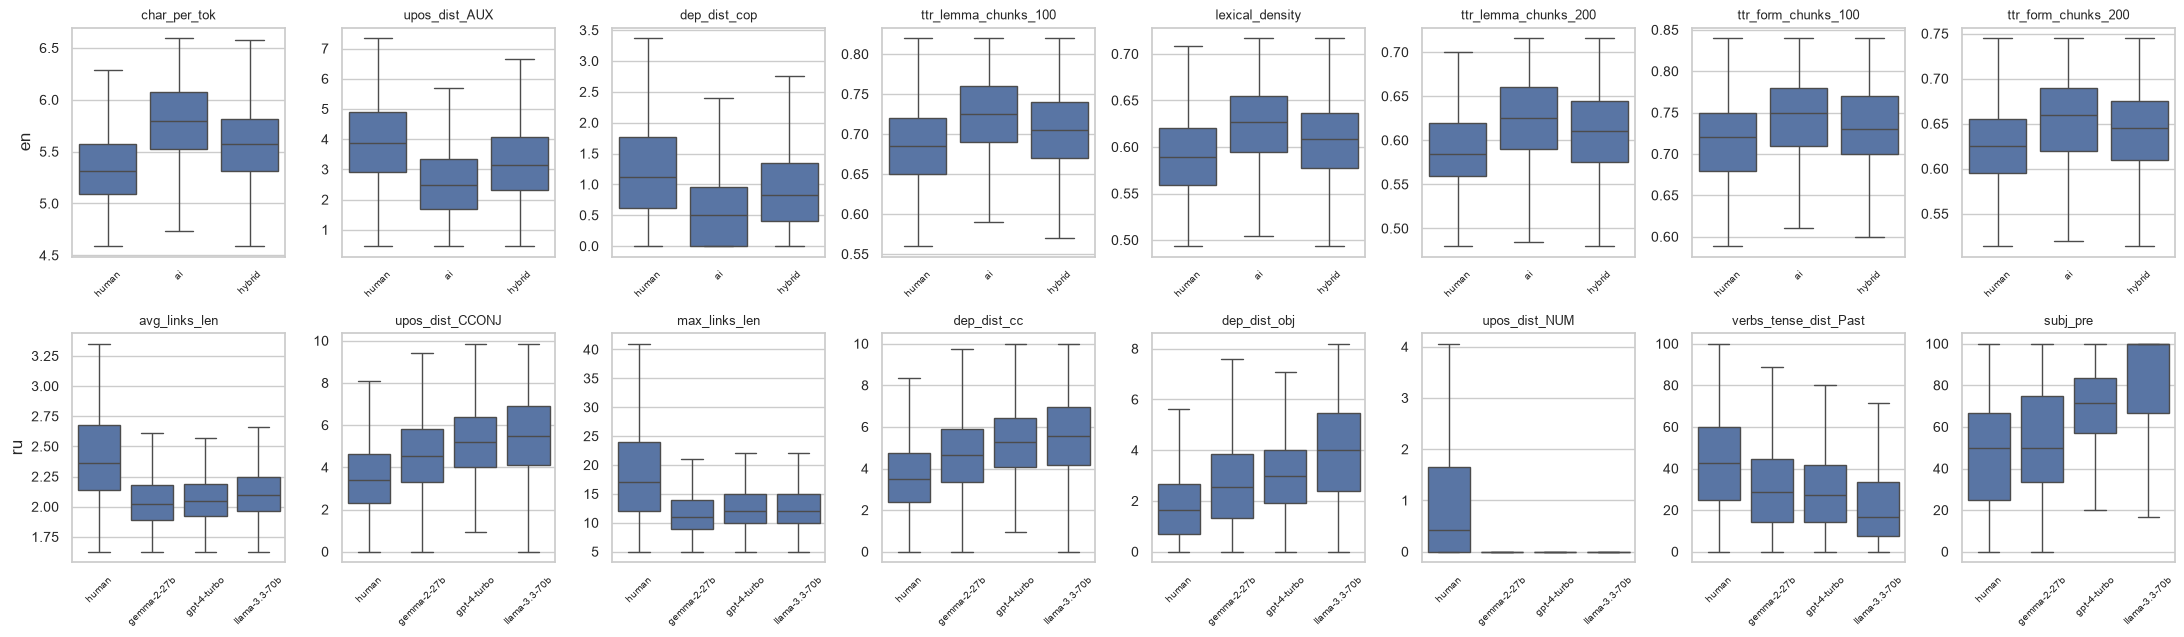

In [8]:
TOP = 8
fig, axes = plt.subplots(2, TOP, figsize=(22, 6.5))
for row, (lang, d, c, hue) in enumerate([('en', en, cmp_en, 'label'), ('ru', ru, cmp_ru, 'model')]):
    for ax, f in zip(axes[row], c.признак.head(TOP)):
        v = prof[lang][f]
        lo, hi = v.quantile([.01, .99])
        sns.boxplot(x=d[hue], y=v.clip(lo, hi), ax=ax, showfliers=False,
                    order=sorted(d[hue].unique(), key=lambda s: s != 'human'))
        ax.set_title(f, fontsize=9); ax.set_xlabel(''); ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
    axes[row, 0].set_ylabel(lang, fontsize=12)
plt.tight_layout(); plt.show()

В английском смешанный класс по всем главным признакам лежит ровно посередине между human и ai, чего и следовало ожидать от текста, собранного из двух половин.

В русском модели заметно отличаются друг от друга. У llama больше всего инфинитивов (19% глаголов против 7–10%) и xcomp, подлежащее у неё стоит первым в 78% случаев. У gemma самые короткие тексты. gpt-4-turbo ближе всех к человеку по длине. Длина текста стоит здесь на первом месте, но большинство признаков различают модели и помимо неё.

### Отбор информативных признаков

Многие признаки дублируют друг друга, например четыре варианта TTR или upos_dist_PUNCT и dep_dist_punct. Беру значимые признаки хотя бы с малым эффектом в порядке силы и пропускаю те, у которых корреляция Спирмена с уже взятым выше 0.8. Получается по 20 признаков на язык.

en: ['char_per_tok', 'upos_dist_AUX', 'dep_dist_cop', 'ttr_lemma_chunks_100', 'lexical_density', 'avg_verb_edges', 'verbal_root_perc', 'dep_dist_aux:pass', 'verbs_verbform_dist_Fin', 'verbs_verbform_dist_Ger', 'verbs_verbform_dist_Part', 'dep_dist_acl', 'dep_dist_obj', 'principal_proposition_dist', 'dep_dist_advcl', 'upos_dist_VERB', 'verbs_verbform_dist_Inf', 'upos_dist_PRON', 'verb_edges_dist_1', 'dep_dist_amod']

ru: ['avg_links_len', 'upos_dist_CCONJ', 'max_links_len', 'dep_dist_obj', 'upos_dist_NUM', 'verbs_tense_dist_Past', 'subj_pre', 'verb_edges_dist_2', 'verbs_person_dist_3', 'n_tokens', 'verbs_verbform_dist_Part', 'verbs_voice_dist_Act', 'dep_dist_nummod', 'dep_dist_punct', 'subordinate_pre', 'upos_dist_NOUN', 'verbs_voice_dist_Mid', 'n_sentences', 'dep_dist_appos', 'dep_dist_iobj']

общие для двух языков: ['dep_dist_obj', 'verbs_verbform_dist_Part']


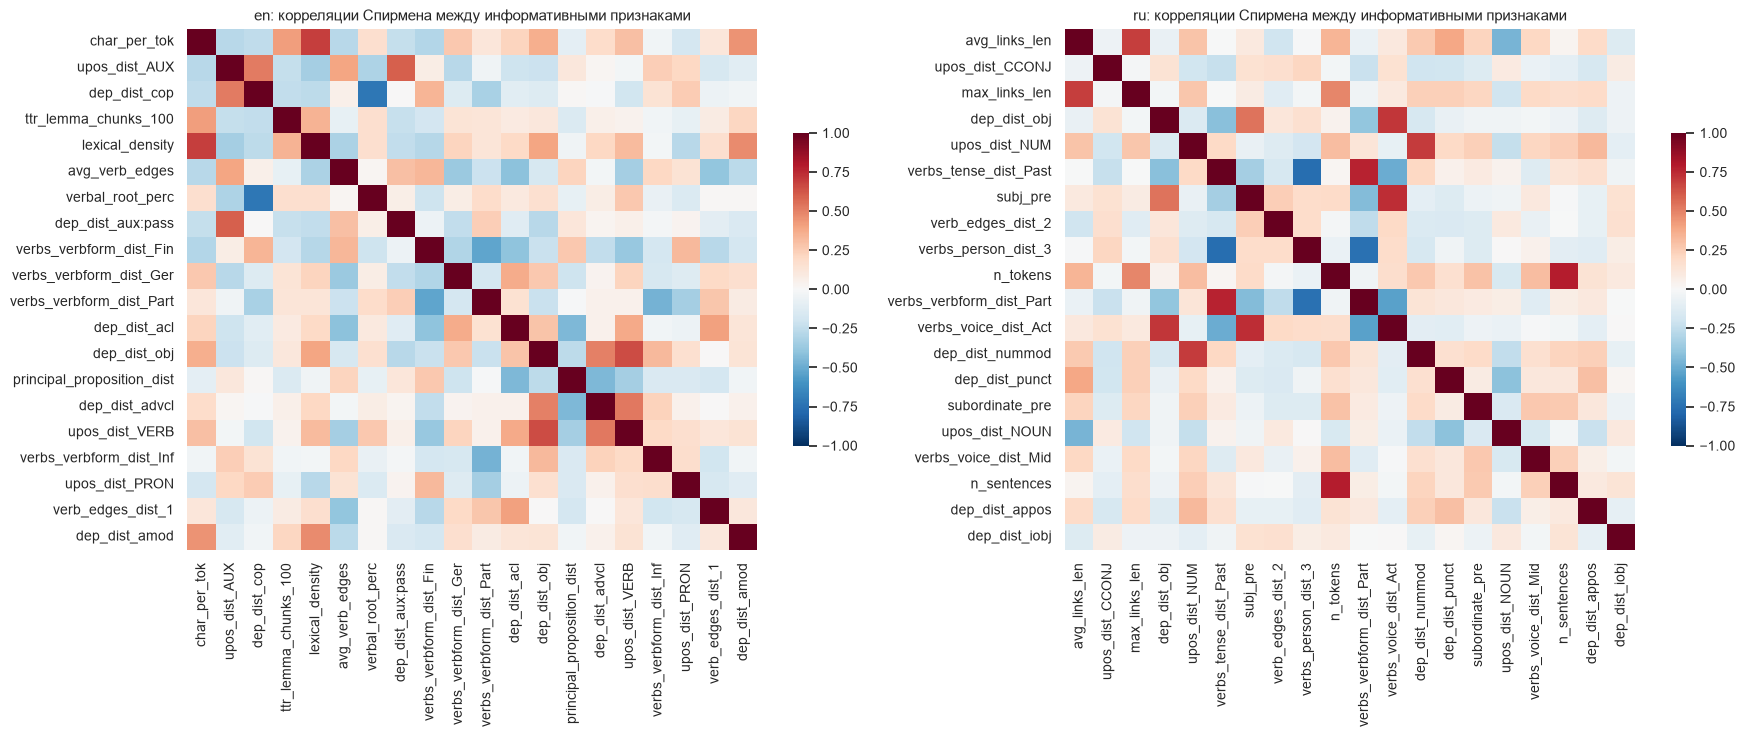

In [9]:
def dedup(c, X, thr=.8, n=20):
    """Идём по признакам в порядке силы, берём признак, если он не дублирует уже взятые."""
    cand = c[(c.p_fdr < .05) & (c.cliff_d.abs() >= .147)].признак
    corr = X[cand].corr(method='spearman').abs()
    keep = []
    for f in cand:
        if all(corr.loc[f, k] < thr for k in keep):
            keep.append(f)
        if len(keep) == n:
            break
    return keep

inf_en, inf_ru = dedup(cmp_en, prof['en']), dedup(cmp_ru, prof['ru'])
print('en:', inf_en); print('\nru:', inf_ru)
print('\nобщие для двух языков:', sorted(set(inf_en) & set(inf_ru)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
for ax, lang, feats in [(axes[0], 'en', inf_en), (axes[1], 'ru', inf_ru)]:
    sns.heatmap(prof[lang][feats].corr(method='spearman'), ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True, cbar_kws={'shrink': .6})
    ax.set_title(f'{lang}: корреляции Спирмена между информативными признаками')
plt.tight_layout(); plt.show()

## 4. Семантические метрики

### BERTScore

Для английского у каждого ИИ- и смешанного текста есть человеческий оригинал, с ним и сравниваю. Модель roberta-large, слой 17, значения rescale по базовой линии авторов метрики. Чтобы было видно масштаб, добавляю базовую линию: чужой человеческий текст из той же научной области.

In [10]:
from bert_score import score as bert_score
from semantic import BARTScorer, LMStats, distinct_n, embed, free, mtld, self_bleu, sentences, tokens

piv = en.pivot(index='pair_id', columns='label', values='text')
dom = en.drop_duplicates('pair_id').set_index('pair_id').domain.reindex(piv.index)
# для базовой линии каждому человеческому тексту подбираем чужой человеческий текст той же области
rng = np.random.default_rng(SEED)
other = piv.human.groupby(dom).transform(lambda s: s.iloc[rng.permutation(len(s))].to_numpy())

def en_bertscore():
    out = {}
    for name, cand in [('ai', piv.ai), ('hybrid', piv.hybrid), ('другой human', other)]:
        P, R, F1 = bert_score(cand.tolist(), piv.human.tolist(), model_type='roberta-large', num_layers=17,
                              batch_size=32, rescale_with_baseline=True, lang='en')
        out[f'{name}_P'], out[f'{name}_R'], out[f'{name}_F1'] = P.numpy(), R.numpy(), F1.numpy()
        free()
    return pd.DataFrame(out, index=piv.index)

bs_en = cached('cache/bertscore_en_pairs.parquet', en_bertscore)
t = pd.DataFrame({k: bs_en[[f'{k}_P', f'{k}_R', f'{k}_F1']].mean().to_numpy()
                  for k in ['ai', 'hybrid', 'другой human']}, index=['P', 'R', 'F1']).T
print('BERTScore относительно исходного человеческого текста, rescaled')
print(t.round(3))

BERTScore относительно исходного человеческого текста, rescaled
                  P      R     F1
ai            0.667  0.648  0.658
hybrid        0.816  0.806  0.811
другой human -0.106 -0.104 -0.104


Пересказ ChatGPT сохраняет смысл: F1 0.66, у случайного текста той же тематики −0.10. У смешанного текста 0.81, потому что половина его дословно совпадает с оригиналом. Precision чуть выше recall: всё, что есть в пересказе, есть и в оригинале, а часть оригинала при пересказе теряется.

В русском датасете пар нет, поэтому там считаю однородность класса, то есть BERTScore между случайными парами текстов одного класса. Для русского беру bert-base-multilingual-cased без rescale, поэтому абсолютные значения двух языков между собой не сравниваются, сравниваются только классы внутри языка.

In [11]:
def intra_bertscore(d, lang, n_pairs=500):
    """Семантическая однородность класса: BERTScore между случайными парами текстов одного класса."""
    rows = []
    kw = dict(model_type='roberta-large', num_layers=17) if lang == 'en' else \
        dict(model_type='google-bert/bert-base-multilingual-cased', num_layers=9)
    for g, s in d.groupby('group').text:
        r = np.random.default_rng(SEED)
        i, j = r.choice(len(s), n_pairs), r.choice(len(s), n_pairs)
        m = i != j
        _, _, F1 = bert_score(s.iloc[i[m]].tolist(), s.iloc[j[m]].tolist(), batch_size=32, **kw)
        rows.append({'lang': lang, 'group': g, 'intra_BERTScore_F1': F1.mean().item()})
        free()
    return pd.DataFrame(rows)

intra = cached('cache/bertscore_intra.parquet', lambda: pd.concat([
    intra_bertscore(en.assign(group=en.label), 'en'),
    intra_bertscore(ru.assign(group=ru.model), 'ru')], ignore_index=True))
print(intra.round(4).to_string(index=False))

lang         group  intra_BERTScore_F1
  en            ai              0.8097
  en         human              0.8027
  en        hybrid              0.8062
  ru   gemma-2-27b              0.6726
  ru   gpt-4-turbo              0.6892
  ru         human              0.6256
  ru llama-3.3-70b              0.6661


Русские ИИ-аннотации между собой похожи сильнее, чем человеческие: 0.67–0.69 против 0.63. Модели пишут по одному шаблону. В английском разница почти нулевая, там ИИ-текст это пересказ человеческого и тематическое разнообразие у него то же.

### BARTScore

BARTScore это средний логарифм вероятности одного текста при условии другого по seq2seq-модели BART, порт из neulab/BARTScore. Для английских пар беру bart-large-cnn, как у авторов. Считаю оба направления, «оригинал → кандидат» (точность) и «кандидат → оригинал» (полнота), и их среднее.

In [12]:
def en_bartscore():
    bart = BARTScorer('facebook/bart-large-cnn')
    out = {}
    for name, cand in [('ai', piv.ai), ('hybrid', piv.hybrid), ('другой human', other)]:
        prec = bart.score(piv.human.tolist(), cand.tolist())
        rec = bart.score(cand.tolist(), piv.human.tolist())
        out[f'{name}_P'], out[f'{name}_R'], out[f'{name}_F'] = prec, rec, (prec + rec) / 2
    del bart; free()
    return pd.DataFrame(out, index=piv.index)

bart_en = cached('cache/bartscore_en_pairs.parquet', en_bartscore)
t = pd.DataFrame({k: bart_en[[f'{k}_P', f'{k}_R', f'{k}_F']].mean().to_numpy()
                  for k in ['ai', 'hybrid', 'другой human']}, index=['human→cand', 'cand→human', 'F']).T
print('BARTScore с исходным человеческим текстом, средний log p на токен')
print(t.round(3))

BARTScore с исходным человеческим текстом, средний log p на токен
              human→cand  cand→human      F
ai                -1.802      -1.977 -1.889
hybrid            -1.094      -1.171 -1.133
другой human      -4.060      -4.061 -4.060


In [13]:
N_BART = 300

def prefix_bartscore():
    """BARTScore без эталона: насколько предсказуемо продолжение текста по его первому предложению."""
    rows = []
    for lang, d, grp, code in [('en', en, 'label', 'en_XX'), ('ru', ru, 'model', 'ru_RU')]:
        bart = BARTScorer('facebook/mbart-large-50', src_lang=code, max_length=320)
        sub = d.groupby(grp, group_keys=False).sample(N_BART, random_state=SEED)
        sp = [sentences(t) for t in sub.text]
        ok = [len(s) > 1 for s in sp]
        sub, sp = sub[ok], [s for s in sp if len(s) > 1]
        sc = bart.score([s[0] for s in sp], [' '.join(s[1:]) for s in sp], batch_size=4)
        rows.append(pd.DataFrame({'lang': lang, 'group': sub[grp].to_numpy(), 'bart_prefix': sc}))
        del bart; free()
    return pd.concat(rows, ignore_index=True)

bart_pref = cached('cache/bartscore_prefix.parquet', prefix_bartscore)
print(bart_pref.groupby(['lang', 'group']).bart_prefix.agg(['mean', 'std', 'count']).round(3))
for lang in ['en', 'ru']:
    b = bart_pref[bart_pref.lang == lang]
    print(f'{lang}: Kruskal p = {stats.kruskal(*[g.bart_prefix for _, g in b.groupby("group")]).pvalue:.2e}')

                      mean    std  count
lang group                              
en   ai            -11.343  2.820    300
     human         -11.898  3.275    300
     hybrid        -11.364  3.117    300
ru   gemma-2-27b    -6.511  1.758    300
     gpt-4-turbo    -7.533  1.888    300
     human          -8.819  3.241    283
     llama-3.3-70b  -5.839  1.894    293
en: Kruskal p = 8.66e-03
ru: Kruskal p = 7.67e-41


Результат согласуется с BERTScore: ai −1.89, hybrid −1.13, чужой текст −4.06. BART намного увереннее выводит пересказ из оригинала, чем чужой текст той же темы.

Для непарных текстов придумала вариант без эталона: условием служит первое предложение, целевым текстом остальная часть. Метрика отвечает на вопрос, насколько предсказуемо продолжение по началу. Модель mbart-large-50, чтобы оба языка считались одинаково, по 300 текстов на класс.

В русском ИИ-тексты намного предсказуемее (от −5.8 у llama до −7.5 у gpt против −8.8 у людей, p < 1e−40). Модель пишет аннотацию так, что уже по первому предложению ясно, что будет дальше. В английском разница слабая (p = 0.009), что естественно: ChatGPT пересказывал готовый человеческий абзац и логику развёртывания унаследовал.

### Self-BLEU

Для каждого текста из выборки в 200 штук считается BLEU против 200 других текстов того же класса, затем берётся среднее. Чем выше Self-BLEU, тем больше тексты класса повторяют одни и те же n-граммы.

In [14]:
def self_bleu_table():
    rows = []
    for lang, d, grp in [('en', en, 'label'), ('ru', ru, 'model')]:
        for g, s in d.groupby(grp).text:
            rows.append({'lang': lang, 'group': g, 'self_BLEU': self_bleu(s.tolist(), n_hyp=200, n_ref=200)})
    return pd.DataFrame(rows)

sb = cached('cache/self_bleu.parquet', self_bleu_table)
print(sb.round(4).to_string(index=False))

lang         group  self_BLEU
  en            ai     0.1071
  en         human     0.1059
  en        hybrid     0.0980
  ru   gemma-2-27b     0.1376
  ru   gpt-4-turbo     0.1313
  ru         human     0.0485
  ru llama-3.3-70b     0.1547


В русском самый сильный из семантических сигналов: Self-BLEU у моделей 0.13–0.15, у людей 0.05, то есть примерно втрое выше. Модели повторяют одни и те же обороты вроде «имеет важное значение для» или «результаты показывают, что». В английском все три класса около 0.10, словарь пересказа привязан к оригиналу.

### Дополнительные метрики

- **log_ppl, entropy, log_rank, top10_share** считаются по GPT-2 для английского и ruGPT-3 small для русского. Это средняя неожиданность токенов, средняя энтропия предсказания (признак из mgt-detection-benchmark), средний логарифм ранга настоящего токена и доля токенов из топ-10 предсказаний.
- **burstiness**: разброс перплексии по предложениям внутри текста. Человек пишет неровно, модель ровнее.
- **distinct-n** и **MTLD**: лексическое разнообразие внутри текста.
- **Однородность эмбеддингов** multilingual-e5: средний косинус между текстами класса.

In [15]:
def text_stats(d, lm_name):
    lm = LMStats(lm_name)
    S = pd.DataFrame(lm(d.text.tolist()))
    del lm; free()
    toks = [tokens(t) for t in d.text]
    S['distinct_1'] = [distinct_n(t, 1) for t in toks]
    S['distinct_2'] = [distinct_n(t, 2) for t in toks]
    S['distinct_3'] = [distinct_n(t, 3) for t in toks]
    S['mtld'] = [mtld(t) for t in toks]
    np.save(f'cache/emb_{d.attrs["lang"]}.npy', embed(d.text.tolist()))
    return S.astype(float)

en.attrs['lang'], ru.attrs['lang'] = 'en', 'ru'
st = {'en': cached('cache/stats_en.parquet', lambda: text_stats(en, 'openai-community/gpt2')),
      'ru': cached('cache/stats_ru.parquet', lambda: text_stats(ru, 'ai-forever/rugpt3small_based_on_gpt2'))}

for lang, d in [('en', en), ('ru', ru)]:
    print(f'\n{lang}: средние по классам')
    print(st[lang].groupby(d.label.to_numpy()).mean().T.round(4))
    c = compare(st[lang], d.label, 'ai', 'human')
    print(c[['признак', 'cliff_d', 'p_fdr']].round(4).to_string(index=False))


en: средние по классам
                   ai    human    hybrid
log_ppl        3.3210   3.5042    3.4435
entropy        3.4924   3.6273    3.5646
log_rank       1.8248   1.9284    1.8965
top10_share    0.6798   0.6646    0.6688
burstiness     0.5189   0.5525    0.5540
distinct_1     0.6716   0.6320    0.6568
distinct_2     0.9446   0.9294    0.9397
distinct_3     0.9861   0.9815    0.9848
mtld         115.8646  92.6626  104.2046
    признак  cliff_d  p_fdr
       mtld   0.3626    0.0
 distinct_1   0.3433    0.0
    log_ppl  -0.2815    0.0
    entropy  -0.2592    0.0
 distinct_2   0.2338    0.0
   log_rank  -0.2226    0.0
top10_share   0.1790    0.0
 distinct_3   0.1404    0.0
 burstiness  -0.0873    0.0

ru: средние по классам
                   ai     human
log_ppl        4.3385    4.3283
entropy        2.9166    2.9512
log_rank       2.3068    2.3638
top10_share    0.6173    0.6043
burstiness     1.1817    1.5793
distinct_1     0.8258    0.7861
distinct_2     0.9714    0.9507
distin

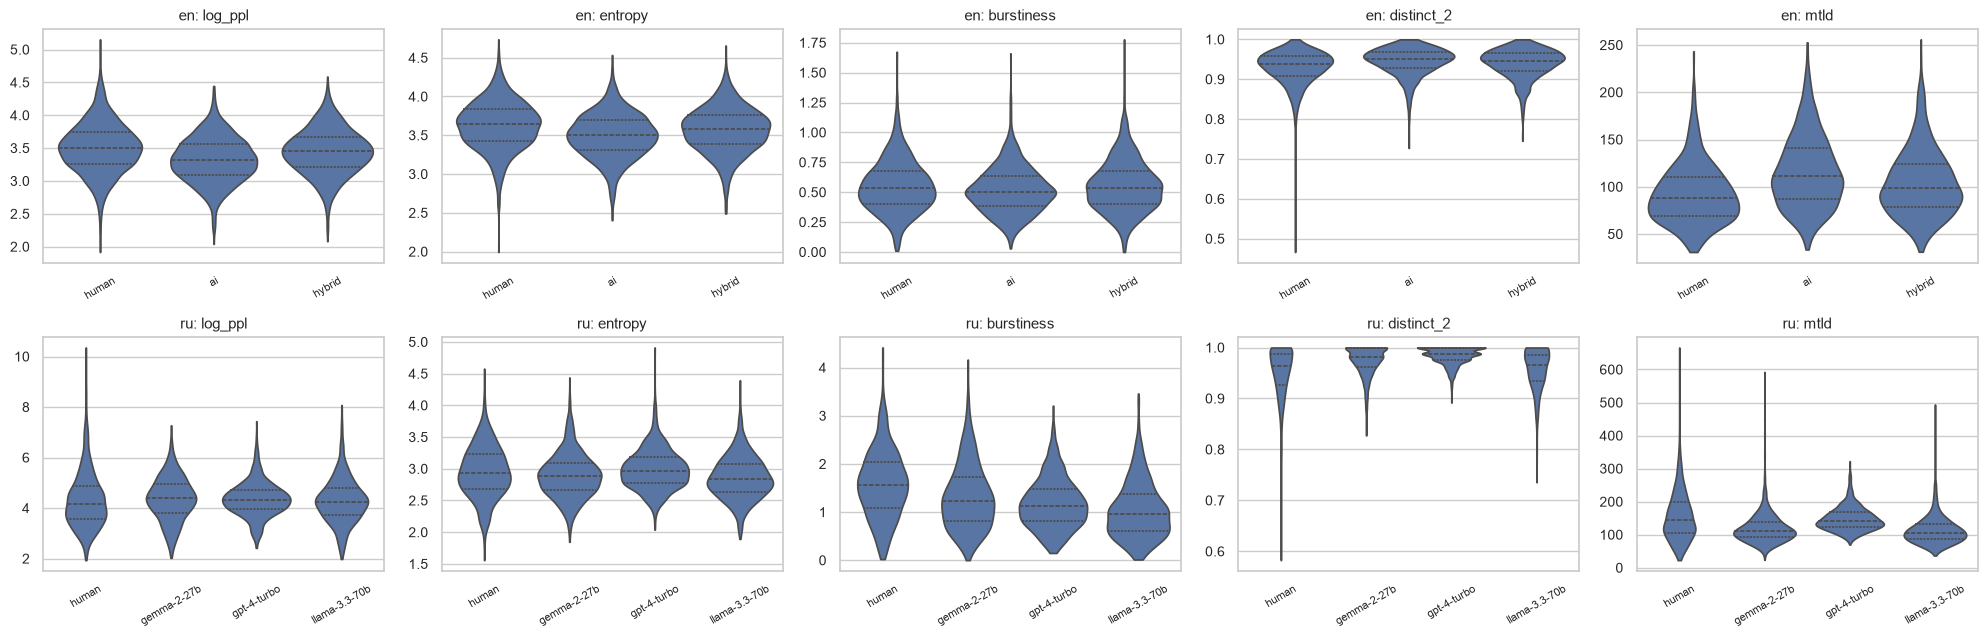

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6.5))
show = ['log_ppl', 'entropy', 'burstiness', 'distinct_2', 'mtld']
for row, (lang, d, hue) in enumerate([('en', en, 'label'), ('ru', ru, 'model')]):
    for ax, f in zip(axes[row], show):
        order = sorted(d[hue].unique(), key=lambda s: s != 'human')
        sns.violinplot(x=d[hue], y=st[lang][f], ax=ax, order=order, cut=0, inner='quartile')
        ax.set_title(f'{lang}: {f}'); ax.set_xlabel(''); ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=30, labelsize=8)
plt.tight_layout(); plt.show()

В английском ИИ-текст для GPT-2 предсказуемее: ниже перплексия и энтропия, больше токенов из топ-10. Лексика у него при этом разнообразнее (MTLD 116 против 93): ChatGPT уходит от повторов, заменяя их синонимами.

В русском перплексия почти не различает классы (эффект 0.07). Зато burstiness работает хорошо: у людей перплексия от предложения к предложению скачет сильнее (1.58 против 1.18). Distinct-n в русском стоит читать осторожно, на коротком тексте он выше просто из-за длины, а ИИ-тексты короче. MTLD от длины зависит меньше и показывает обратное: у людей лексика разнообразнее.

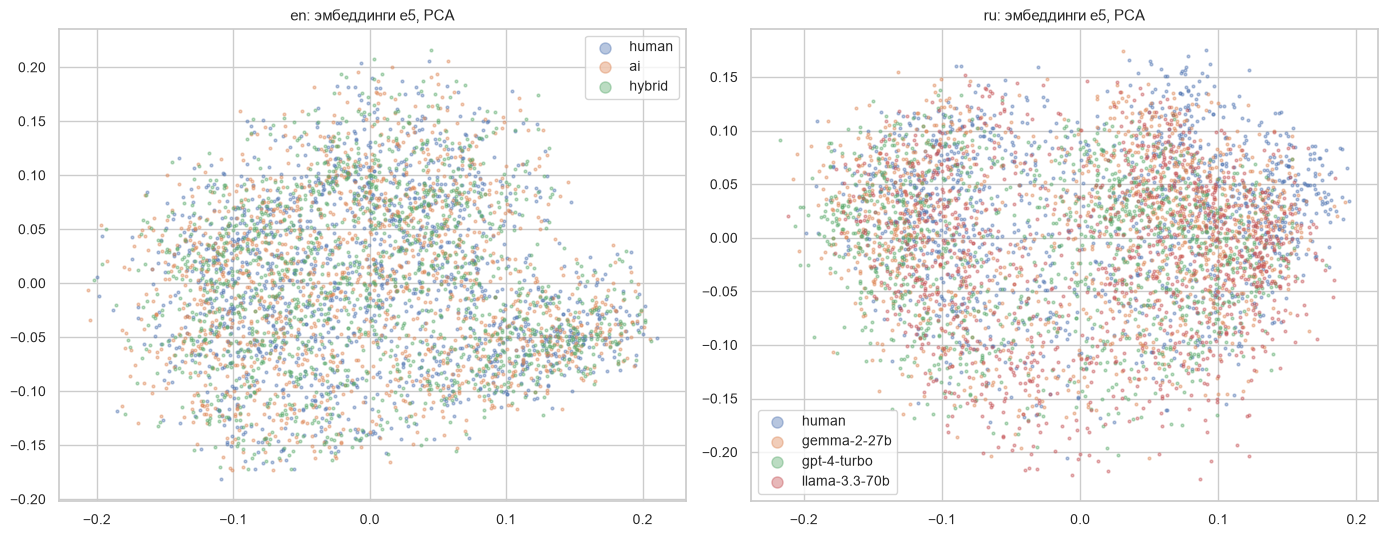

en: средний косинус между текстами одного класса {'ai': np.float32(0.8037), 'human': np.float32(0.8045), 'hybrid': np.float32(0.8039)}
ru: средний косинус между текстами одного класса {'gemma-2-27b': np.float32(0.8327), 'gpt-4-turbo': np.float32(0.8451), 'human': np.float32(0.8281), 'llama-3.3-70b': np.float32(0.8215)}


In [17]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (lang, d, hue) in zip(axes, [('en', en, 'label'), ('ru', ru, 'model')]):
    E = np.load(f'cache/emb_{lang}.npy')
    Z = PCA(2, random_state=SEED).fit_transform(E)
    for g in sorted(d[hue].unique(), key=lambda s: s != 'human'):
        m = (d[hue] == g).to_numpy()
        ax.scatter(Z[m, 0], Z[m, 1], s=4, alpha=.4, label=g)
    ax.set_title(f'{lang}: эмбеддинги e5, PCA'); ax.legend(markerscale=4)
plt.tight_layout(); plt.show()

for lang, d, hue in [('en', en, 'label'), ('ru', ru, 'model')]:
    E = np.load(f'cache/emb_{lang}.npy')
    rows = {}
    for g in d[hue].unique():
        m = (d[hue] == g).to_numpy()
        C = E[m] @ E[m].T
        rows[g] = C[np.triu_indices(m.sum(), 1)].mean()
    print(f'{lang}: средний косинус между текстами одного класса', {k: round(v, 4) for k, v in sorted(rows.items())})

Тематически классы на эмбеддингах не разделяются, облака совпадают. Модели писали на те же темы, что и люди, и различие лежит в стиле, а не в содержании. По косинусу внутри класса самый однородный gpt-4-turbo (0.845), llama даже чуть разнообразнее людей.

### Что показала семантика

| Метрика | Английский | Русский |
|---|---|---|
| BERTScore с оригиналом | ai 0.66, hybrid 0.81, чужой текст −0.10 | нет пар |
| BERTScore внутри класса | классы равны | ai 0.67–0.69, human 0.63 |
| BARTScore с оригиналом | ai −1.89, hybrid −1.13, чужой текст −4.06 | нет пар |
| BARTScore префикс → остаток | слабая разница | ai заметно предсказуемее |
| Self-BLEU | классы равны | ai 0.13–0.15, human 0.05 |
| Перплексия | у ai ниже | почти равна |
| Burstiness | у ai чуть ниже | у ai заметно ниже |

В английском ИИ-текст это пересказ, и главные отличия у него стилистические: другой словарь и другой синтаксис. В русском ИИ-тексты написаны с нуля, поэтому они шаблоннее: похожи друг на друга, предсказуемы по началу и ровнее по перплексии.

## 5. Классификация

Четыре задачи: human против ai и три класса для английского, human против ai и четыре источника для русского. Наборы признаков:

- **только длина** (токены и предложения), чтобы увидеть, сколько даёт одна длина;
- **Profiling-UD**, все 99 признаков;
- **Profiling-UD, информативные**, 20 отобранных в разделе 3;
- **LM и лексика**, метрики из раздела 4, которые считаются по одному тексту;
- **Profiling-UD + LM и лексика**;
- **TF-IDF слов** с LogReg, стандартная базовая линия (в AINL-Eval она официальная).

Модели: логистическая регрессия, SVM с RBF-ядром, случайный лес и XGBoost. Проверка на 5 фолдах. В английском это GroupKFold по номеру строки, чтобы три версии одного абзаца не расходились между обучением и тестом, иначе модель запоминает тему. В русском это стратифицированный KFold. Метрики как в mgt-detection-benchmark: accuracy, macro F1, AUC.

Оговорка: 20 информативных признаков отбирались по всей выборке, это небольшая утечка. На результат она не влияет, потому что этот набор всё равно хуже полного.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

MODELS = {
    'LogReg':  lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=3000)),
    'SVM':     lambda: make_pipeline(StandardScaler(), SVC(C=2, probability=True, random_state=SEED)),
    'RF':      lambda: RandomForestClassifier(500, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    'XGBoost': lambda: XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                                     colsample_bytree=0.6, n_jobs=-1, random_state=SEED),
}

def folds(d, y):
    # в AIGTxt три текста одной строки это пересказы одного абзаца, их нельзя разносить по фолдам
    if 'pair_id' in d:
        return list(GroupKFold(5).split(d, y, groups=d.pair_id))
    return list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(d, y))

def evaluate(X, y, splits, model):
    y = LabelEncoder().fit_transform(y)
    proba = np.zeros((len(y), y.max() + 1))
    for tr, te in splits:
        m = model().fit(X[tr], y[tr])
        proba[te] = m.predict_proba(X[te])
    pred = proba.argmax(1)
    auc = roc_auc_score(y, proba[:, 1]) if proba.shape[1] == 2 else roc_auc_score(y, proba, multi_class='ovr')
    return {'accuracy': accuracy_score(y, pred), 'macro_F1': f1_score(y, pred, average='macro'), 'AUC': auc}, proba

In [19]:
TASKS = {
    'en: human vs ai':             (en, en.label.isin(['human', 'ai']), 'label'),
    'en: human / ai / hybrid':     (en, en.label.notna(), 'label'),
    'ru: human vs ai':             (ru, ru.label.notna(), 'label'),
    'ru: human / gpt / llama / gemma': (ru, ru.label.notna(), 'model'),
}
STAT_COLS = ['log_ppl', 'entropy', 'log_rank', 'top10_share', 'burstiness', 'distinct_1', 'distinct_2',
             'distinct_3', 'mtld']

def feature_sets(lang, d, m):
    ud_ = prof[lang][m].fillna(prof[lang].median())
    st_ = st[lang].loc[m, STAT_COLS].fillna(st[lang][STAT_COLS].median())
    return {'Profiling-UD': ud_.to_numpy(),
            'Profiling-UD, информативные': ud_[inf_en if lang == 'en' else inf_ru].to_numpy(),
            'LM и лексика': st_.to_numpy(),
            'Profiling-UD + LM и лексика': np.c_[ud_.to_numpy(), st_.to_numpy()],
            'только длина': ud_[['n_tokens', 'n_sentences']].to_numpy()}

def run_all():
    rows = []
    for task, (d, m, target) in TASKS.items():
        lang = task[:2]
        dm, y = d[m.to_numpy()].reset_index(drop=True), d.loc[m, target].to_numpy()
        splits = folds(dm, y)
        for fs, X in feature_sets(lang, d, m.to_numpy()).items():
            for name, model in MODELS.items():
                res, _ = evaluate(X, y, splits, model)
                rows.append({'задача': task, 'признаки': fs, 'модель': name, **res})
        # базовая линия на словах, словарь TF-IDF строится внутри фолда
        tfidf = lambda: make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000,
                                                      sublinear_tf=True), LogisticRegression(C=5, max_iter=3000))
        res, _ = evaluate(dm.text.to_numpy(), y, splits, tfidf)
        rows.append({'задача': task, 'признаки': 'TF-IDF слов', 'модель': 'LogReg', **res})
        print(f'{task}: готово')
    return pd.DataFrame(rows)

clf = cached('cache/classification.parquet', run_all)
clf.to_csv('results/classification.csv', index=False)

In [20]:
for task in TASKS:
    t = clf[clf.задача == task].pivot_table(index='признаки', columns='модель', values='macro_F1')
    t = t[['LogReg', 'SVM', 'RF', 'XGBoost']].loc[['только длина', 'Profiling-UD', 'Profiling-UD, информативные',
                                                    'LM и лексика', 'Profiling-UD + LM и лексика', 'TF-IDF слов']]
    print(f'\n{task}, macro F1, 5 фолдов')
    print(t.round(3).to_string())


en: human vs ai, macro F1, 5 фолдов
модель                       LogReg    SVM     RF  XGBoost
признаки                                                  
только длина                  0.512  0.573  0.541    0.514
Profiling-UD                  0.842  0.841  0.812    0.836
Profiling-UD, информативные   0.813  0.811  0.803    0.799
LM и лексика                  0.719  0.722  0.703    0.694
Profiling-UD + LM и лексика   0.863  0.867  0.831    0.856
TF-IDF слов                   0.948    NaN    NaN      NaN

en: human / ai / hybrid, macro F1, 5 фолдов
модель                       LogReg    SVM     RF  XGBoost
признаки                                                  
только длина                  0.315  0.325  0.368    0.346
Profiling-UD                  0.594  0.585  0.558    0.587
Profiling-UD, информативные   0.561  0.554  0.552    0.557
LM и лексика                  0.486  0.477  0.457    0.454
Profiling-UD + LM и лексика   0.634  0.627  0.574    0.613
TF-IDF слов                   0.6

Profiling-UD даёт 0.84 на английском и 0.92 на русском. Добавление LM-признаков поднимает результат на 1–4 пункта, значит признаки частично друг друга дополняют. Сами по себе LM-признаки слабее синтаксиса. Отобранные 20 признаков уступают полному набору 2–6 пунктов: сигнал размазан по множеству слабых признаков. Чаще всего лучшая модель SVM, XGBoost и LogReg отстают на доли пункта.

Длина в английском ничего не даёт (0.51–0.57). В русском она даёт 0.82 в бинарной задаче. Это сильная подсказка, но Profiling-UD прибавляет к ней ещё 10 пунктов, а в четырёх классах 24.

TF-IDF выигрывает везде, особенно в английском (0.95) и в четырёх классах русского (0.93 против 0.84). Выбор конкретных слов выдаёт модель надёжнее синтаксиса, у каждой модели свой набор любимых оборотов. Зато признаки Profiling-UD интерпретируемы и не привязаны к теме, поэтому лучше подходят для анализа, ради которого и делалось задание.

### Базовая линия из mgt-detection-benchmark

Воспроизвожу статистический метод из 05_entropy_rf_tuned.py: единственный признак, средняя энтропия языковой модели, и случайный лес с подбором гиперпараметров по случайной сетке.

In [21]:
def entropy_rf():
    """Как в 05_entropy_rf_tuned.py из mgt-detection-benchmark: энтропия LM плюс RF с подбором по сетке."""
    grid = {'n_estimators': [50, 100, 300], 'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', None],
            'max_depth': [None, 10], 'min_samples_split': [2, 4, 6], 'min_samples_leaf': [1, 3]}
    tuned = lambda: RandomizedSearchCV(RandomForestClassifier(random_state=SEED, n_jobs=-1), grid, n_iter=20,
                                       cv=3, random_state=SEED)
    rows = []
    for task, (d, m, target) in TASKS.items():
        lang = task[:2]
        dm, y = d[m.to_numpy()].reset_index(drop=True), d.loc[m, target].to_numpy()
        X = st[lang].loc[m.to_numpy(), ['entropy']].to_numpy()
        res, _ = evaluate(X, y, folds(dm, y), tuned)
        rows.append({'задача': task, **res})
    return pd.DataFrame(rows)

bench = cached('cache/entropy_rf.parquet', entropy_rf)
best = clf.sort_values('macro_F1', ascending=False).groupby('задача', sort=False).head(1)
t = bench[['задача', 'macro_F1', 'AUC']].rename(columns={'macro_F1': 'F1 энтропия+RF', 'AUC': 'AUC энтропия+RF'})
t = t.merge(best[['задача', 'признаки', 'модель', 'macro_F1']].rename(columns={'macro_F1': 'F1 лучшая'}), on='задача')
print(t.round(3).to_string(index=False))

                         задача  F1 энтропия+RF  AUC энтропия+RF    признаки модель  F1 лучшая
                en: human vs ai           0.572            0.594 TF-IDF слов LogReg      0.948
        en: human / ai / hybrid           0.369            0.550 TF-IDF слов LogReg      0.671
                ru: human vs ai           0.470            0.526 TF-IDF слов LogReg      0.934
ru: human / gpt / llama / gemma           0.266            0.534 TF-IDF слов LogReg      0.926


Одной энтропии мало, 0.57 на английском и 0.47 на русском. В русском бинарном случае лес почти всегда отвечает ai, это мажоритарный класс. Анализ по многим признакам нужен именно потому, что одного показателя не хватает.

### Матрицы ошибок

XGBoost на Profiling-UD + LM, доли по строкам.

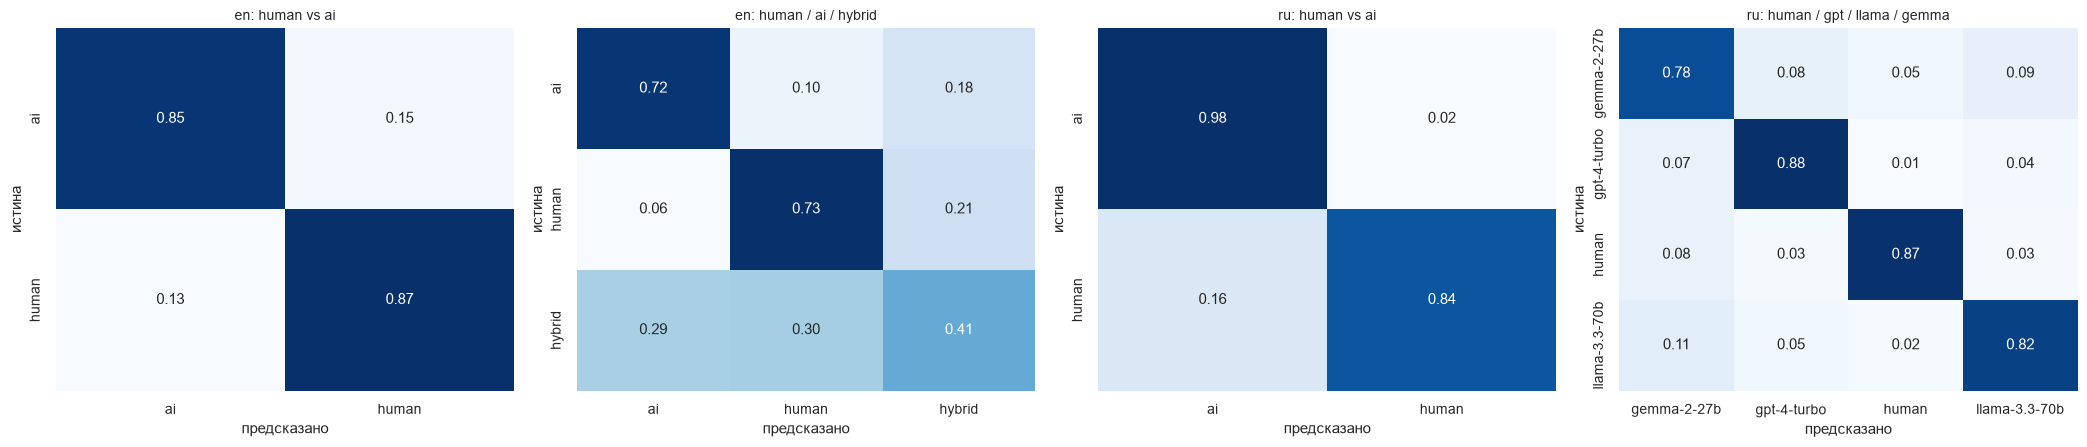

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(21, 4.6))
for ax, (task, (d, m, target)) in zip(axes, TASKS.items()):
    lang = task[:2]
    dm, y = d[m.to_numpy()].reset_index(drop=True), d.loc[m, target].to_numpy()
    X = feature_sets(lang, d, m.to_numpy())['Profiling-UD + LM и лексика']
    _, proba = evaluate(X, y, folds(dm, y), MODELS['XGBoost'])
    le = LabelEncoder().fit(y)
    cm = confusion_matrix(le.transform(y), proba.argmax(1), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar=False,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(task, fontsize=10); ax.set_xlabel('предсказано'); ax.set_ylabel('истина')
plt.tight_layout(); plt.show()

Смешанные тексты главная проблема: верно определяется только 41%, остальные делятся между human и ai почти поровну. Ничего удивительного, ведь половина такого текста человеческая, а половина от ChatGPT, и признаки, усреднённые по тексту, дают середину. Для гибридов нужна разметка на уровне предложений.

В русском люди чаще путаются с ai (16%), чем наоборот (2%). Среди моделей лучше всего узнаётся gpt-4-turbo (0.88), gemma и llama чаще путаются между собой.

### Что использует модель

SHAP-вклады XGBoost в бинарной задаче. Сравниваю с рангом признака в статистическом анализе из раздела 3.

In [23]:
import xgboost as xgb_lib

for lang, d in [('en', en), ('ru', ru)]:
    m = d.label.isin(['human', 'ai']).to_numpy()
    X = pd.concat([prof[lang][m], st[lang].loc[m, STAT_COLS]], axis=1).fillna(0)
    y = (d.label[m] == 'ai').astype(int).to_numpy()
    xgb = MODELS['XGBoost']().fit(X, y)
    # SHAP-вклады встроенным методом xgboost, последний столбец это bias
    sv = xgb.get_booster().predict(xgb_lib.DMatrix(X), pred_contribs=True)[:, :-1]
    imp = pd.Series(np.abs(sv).mean(0), index=X.columns).sort_values(ascending=False)
    c = (cmp_en if lang == 'en' else cmp_ru).set_index('признак')
    rank = c.cliff_d.abs().rank(ascending=False)
    top = imp.head(12).to_frame('mean|SHAP|')
    top['ранг в стат. анализе'] = [int(rank[f]) if f in rank else '-' for f in top.index]
    print(f'\n{lang}: human vs ai, топ 12 признаков XGBoost')
    print(top.round(4).to_string())


en: human vs ai, топ 12 признаков XGBoost
                            mean|SHAP| ранг в стат. анализе
char_per_tok                    1.0783                    1
log_ppl                         0.6744                    -
upos_dist_AUX                   0.5706                    2
dep_dist_conj                   0.3659                   49
dep_dist_advcl                  0.2658                   20
distinct_1                      0.2450                    -
dep_dist_cop                    0.2439                    3
verbs_verbform_dist_Inf         0.2330                   22
upos_dist_PROPN                 0.2265                   76
principal_proposition_dist      0.2190                   18
dep_dist_nmod:poss              0.2072                   45
verbs_verbform_dist_Part        0.1981                   14



ru: human vs ai, топ 12 признаков XGBoost
                          mean|SHAP| ранг в стат. анализе
n_tokens                      0.6657                   11
avg_links_len                 0.5992                    1
subj_pre                      0.5568                    8
n_sentences                   0.4365                   23
upos_dist_CCONJ               0.3996                    2
top10_share                   0.2915                    -
upos_dist_NUM                 0.2783                    6
verb_edges_dist_2             0.2750                    9
verbs_voice_dist_Mid          0.2664                   20
verbs_verbform_dist_Conv      0.2447                   59
dep_dist_iobj                 0.2364                   26
verbs_person_dist_3           0.2127                   10


Верхние признаки модели и статистического анализа в основном совпадают: char_per_tok, AUX и cop в английском, avg_links_len, subj_pre, CCONJ и NUM в русском. Модель добавляет log_ppl в английском и top10_share в русском, то есть LM-признаки несут информацию, которой нет в синтаксисе. В русском модель опирается на длину (n_tokens, n_sentences), это ожидаемо после раздела 1.

## Итог

**Лингвостатистика.** ИИ-тексты отличаются по многим признакам Profiling-UD: 71 из 92 значимых в английском, 83 из 92 в русском. При этом средний или большой эффект есть только у 10–14 признаков.

| | Английский (пересказ ChatGPT) | Русский (генерация с нуля) |
|---|---|---|
| Лексика | длиннее слова, выше TTR и лексическая плотность | беднее лексика (ниже MTLD), нет чисел |
| Морфология | меньше AUX и связок, больше Part и Ger | меньше прошедшего времени и причастий, больше Act и третьего лица |
| Синтаксис | глагол чаще в корне, меньше зависимых у глагола | короче связи, больше сочинения и obj, подлежащее чаще первым |

**Семантика.** Пересказ сохраняет смысл оригинала: BERTScore 0.66, BARTScore −1.9 при −4.1 у чужого текста. ИИ-аннотации на русском шаблоннее человеческих: они втрое выше по Self-BLEU, ближе друг к другу по BERTScore, предсказуемее по началу текста и ровнее по перплексии.

**Классификация**, macro F1 на 5 фолдах, лучшая модель в строке:

| Задача | Длина | Profiling-UD | + LM и лексика | TF-IDF | Энтропия + RF |
|---|---|---|---|---|---|
| en: human vs ai | 0.57 | 0.84 | 0.87 | 0.95 | 0.57 |
| en: три класса | 0.37 | 0.59 | 0.63 | 0.67 | 0.37 |
| ru: human vs ai | 0.82 | 0.92 | 0.93 | 0.93 | 0.47 |
| ru: четыре источника | 0.58 | 0.82 | 0.84 | 0.93 | 0.27 |

**Ограничения.**

- Признаки Profiling-UD считаются локально по разбору stanza, а не веб-сервисом, который использует UDPipe. Названия и определения совпадают, но абсолютные значения могут немного отличаться из-за разных парсеров.
- В русском классы различаются по длине. Частная корреляция показывает, что основные различия остаются и с поправкой на длину, но классификатор длину использует.
- Выборки взяты подмножествами (4500 и 4800 текстов), иначе разбор и языковые модели считались бы несколько часов.
- Проверка только внутри датасета. Как признаки переносятся на новые модели и новые научные области, здесь не проверено, а в AINL-Eval это отдельная часть задачи.